## Import the required modules

In [6]:
import matplotlib.pyplot as plt
import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any, Dict, Callable
from QMAP_tools.qmap_inspector import QMAPInspector

In [7]:
# Not required but improved the default layout of plots
import scienceplots
plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

## Getting familiar with the database

QMAP produces two databases a "full_db" and a "agg_db" these can either be loaded using pandas/polars and contain the full data set and aggregated full dataset respectively.

```IMPORTANT: DO NOT LOAD THE FULL "full_db" AS REQUIRES ~100GB OF RAM```
Instead aim to use streaming / pre-filtering to make memory requirements manageable as shown below

In [8]:
qm = QMAPInspector()
# Load the helper class which by default has the standard relative paths of the database files so should work out of the box
# in most cases, however if the data is stored else where just use the init kwargs to set the correct path

In [9]:
qm.full_db.filter(pl.col("i") == 1).collect()
# The full database contains all the data needed to make the agg_db and some. It is very important that you do not try load
# the full database into memory so when previewing a standard way is to just filter by pl.col("i") == 1 which restricts the
# database to 1 / 8192 of its full size and therefore can be fully loaded into memory. We are still able to do operations
# on this dataset as you will see later leveraging the LazyFrame.

i,j,face,area,TIR detailed_survey tri_num,TIR detailed_survey band depth 350,TIR detailed_survey band depth 440,TIR detailed_survey slope 1000,TIR detailed_survey ratio 1000,TIR detailed_survey sigma band depth 350,TIR detailed_survey sigma band depth 440,TIR detailed_survey sigma slope 1000,TIR detailed_survey sigma ratio 1000,TIR recona tri_num,TIR recona band depth 350,TIR recona band depth 440,TIR recona slope 1000,TIR recona ratio 1000,TIR recona sigma band depth 350,TIR recona sigma band depth 440,TIR recona sigma slope 1000,TIR recona sigma ratio 1000,TIR reconb tri_num,TIR reconb band depth 350,TIR reconb band depth 440,TIR reconb slope 1000,TIR reconb ratio 1000,TIR reconb sigma band depth 350,TIR reconb sigma band depth 440,TIR reconb sigma slope 1000,TIR reconb sigma ratio 1000,VNIR detailed_survey tri_num,VNIR detailed_survey band depth,VNIR detailed_survey reflectance,VNIR detailed_survey slope1 poly,VNIR detailed_survey slope2 poly,VNIR detailed_survey sigma band depth,…,VNIR recona sigma slope2 poly,VNIR reconc tri_num,VNIR reconc band depth,VNIR reconc reflectance,VNIR reconc slope1 poly,VNIR reconc slope2 poly,VNIR reconc sigma band depth,VNIR reconc sigma reflectance,VNIR reconc sigma slope1 poly,VNIR reconc sigma slope2 poly,uint8_reflectance,32bit_reflectance,positions_x,positions_y,positions_z,detection_lod_level,detection_lod_code,boulder_id,Gamma,Tau,Area,center_x,min_x,max_x,center_y,min_y,max_y,center_z,min_z,max_z,number_of_samples,TIR detailed_survey tri_num alpha,TIR recona tri_num alpha,TIR reconb tri_num alpha,VNIR detailed_survey tri_num alpha,VNIR recona tri_num alpha,VNIR reconc tri_num alpha
u32,u32,str,f32,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u64,f64,f64,f64,f64,f64,…,f64,u64,f64,f64,f64,f64,f64,f64,f64,f64,u8,f32,f32,f32,f32,u8,str,u32,f64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,u32,u32,u32,u32,u32,u32,u32
1,2001,"""negx""",0.001015,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,52,0.009051,0.079066,0.154651,-0.154623,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2002,"""negx""",0.001057,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,63,0.010972,0.079029,0.154657,-0.154623,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2003,"""negx""",0.001048,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,74,0.012779,0.07899,0.154662,-0.154624,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,2004,"""negx""",0.000999,27133,1.002981,1.01124,1.001634,null,0.000949,0.000572,0.000803,null,433656,null,null,null,null,null,null,null,null,433656,null,null,null,null,null,null,null,null,108539,null,null,null,null,null,…,null,1734640,null,null,null,null,null,null,null,null,88,0.015247,0.078953,0.154663,-0.154628,0,"""""",5175,2.669787,1.75751,30.795101,0.079715,0.074881,0.083552,0.155437,0.153171,0.156941,-0.152862,-0.154658,-0.150324,29952,15279,919,919,4005,919,230
1,1920,"""negx""",0.000975,27132,1.003123,1.01109,1.001736,null,0.001058,0.000682,0.000824,null,432631,null,null,null,null,null,null,null,null,432631,nu

Text(0, 0.5, 'y')

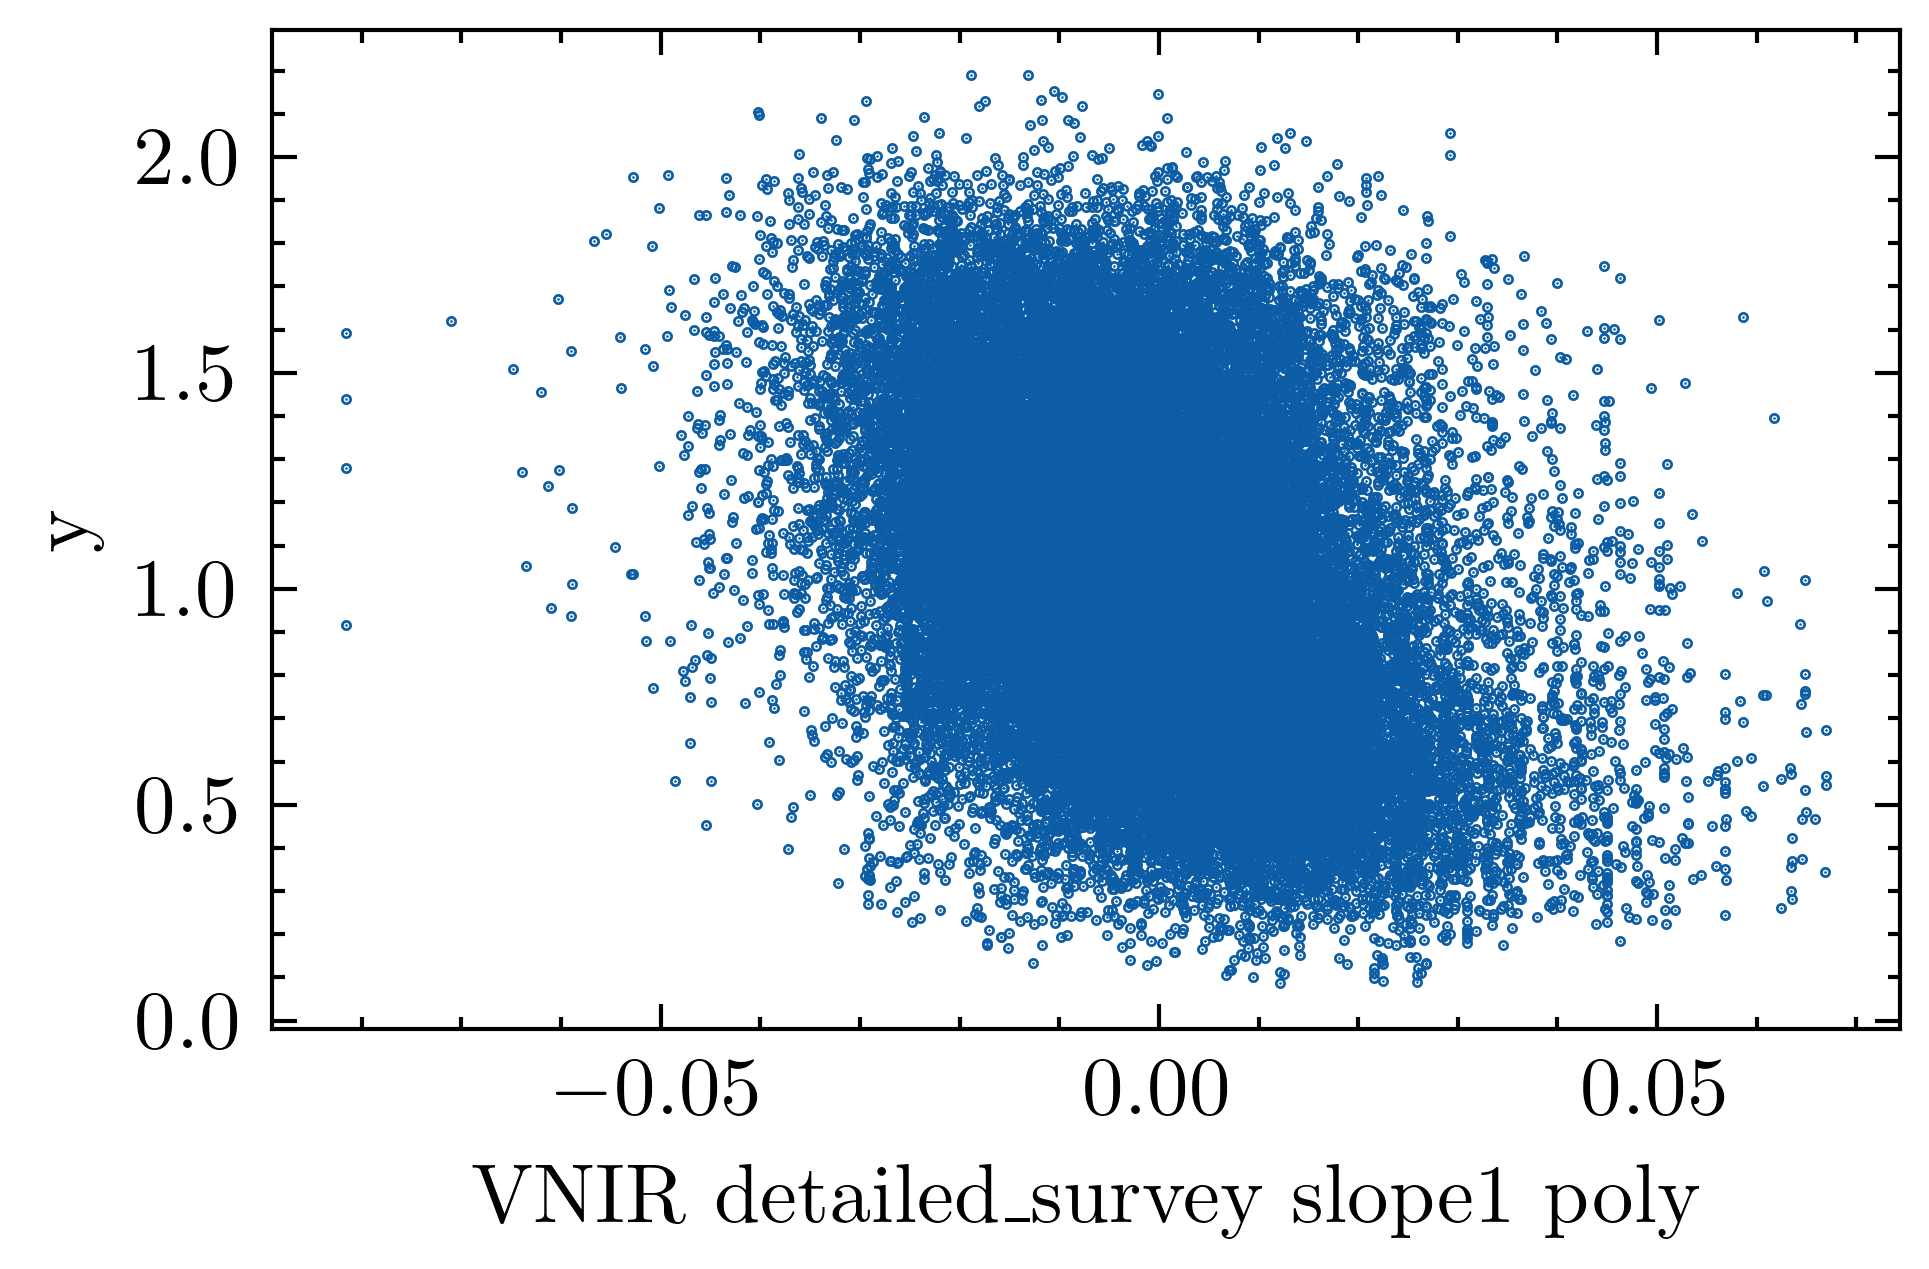

In [24]:
facet_agg = (
    qm.full_db
    .group_by("VNIR detailed_survey tri_num")
    .agg(
        pl.col("VNIR detailed_survey slope1 poly").first().alias("x"),

        ((pl.col("32bit_reflectance").log()).std())
        .alias("y"),
    )
    .collect(engine="streaming")
)

facet_agg

plt.scatter(facet_agg["x"], facet_agg["y"], s=0.1)
plt.xlabel("VNIR detailed_survey slope1 poly")
plt.ylabel("y")

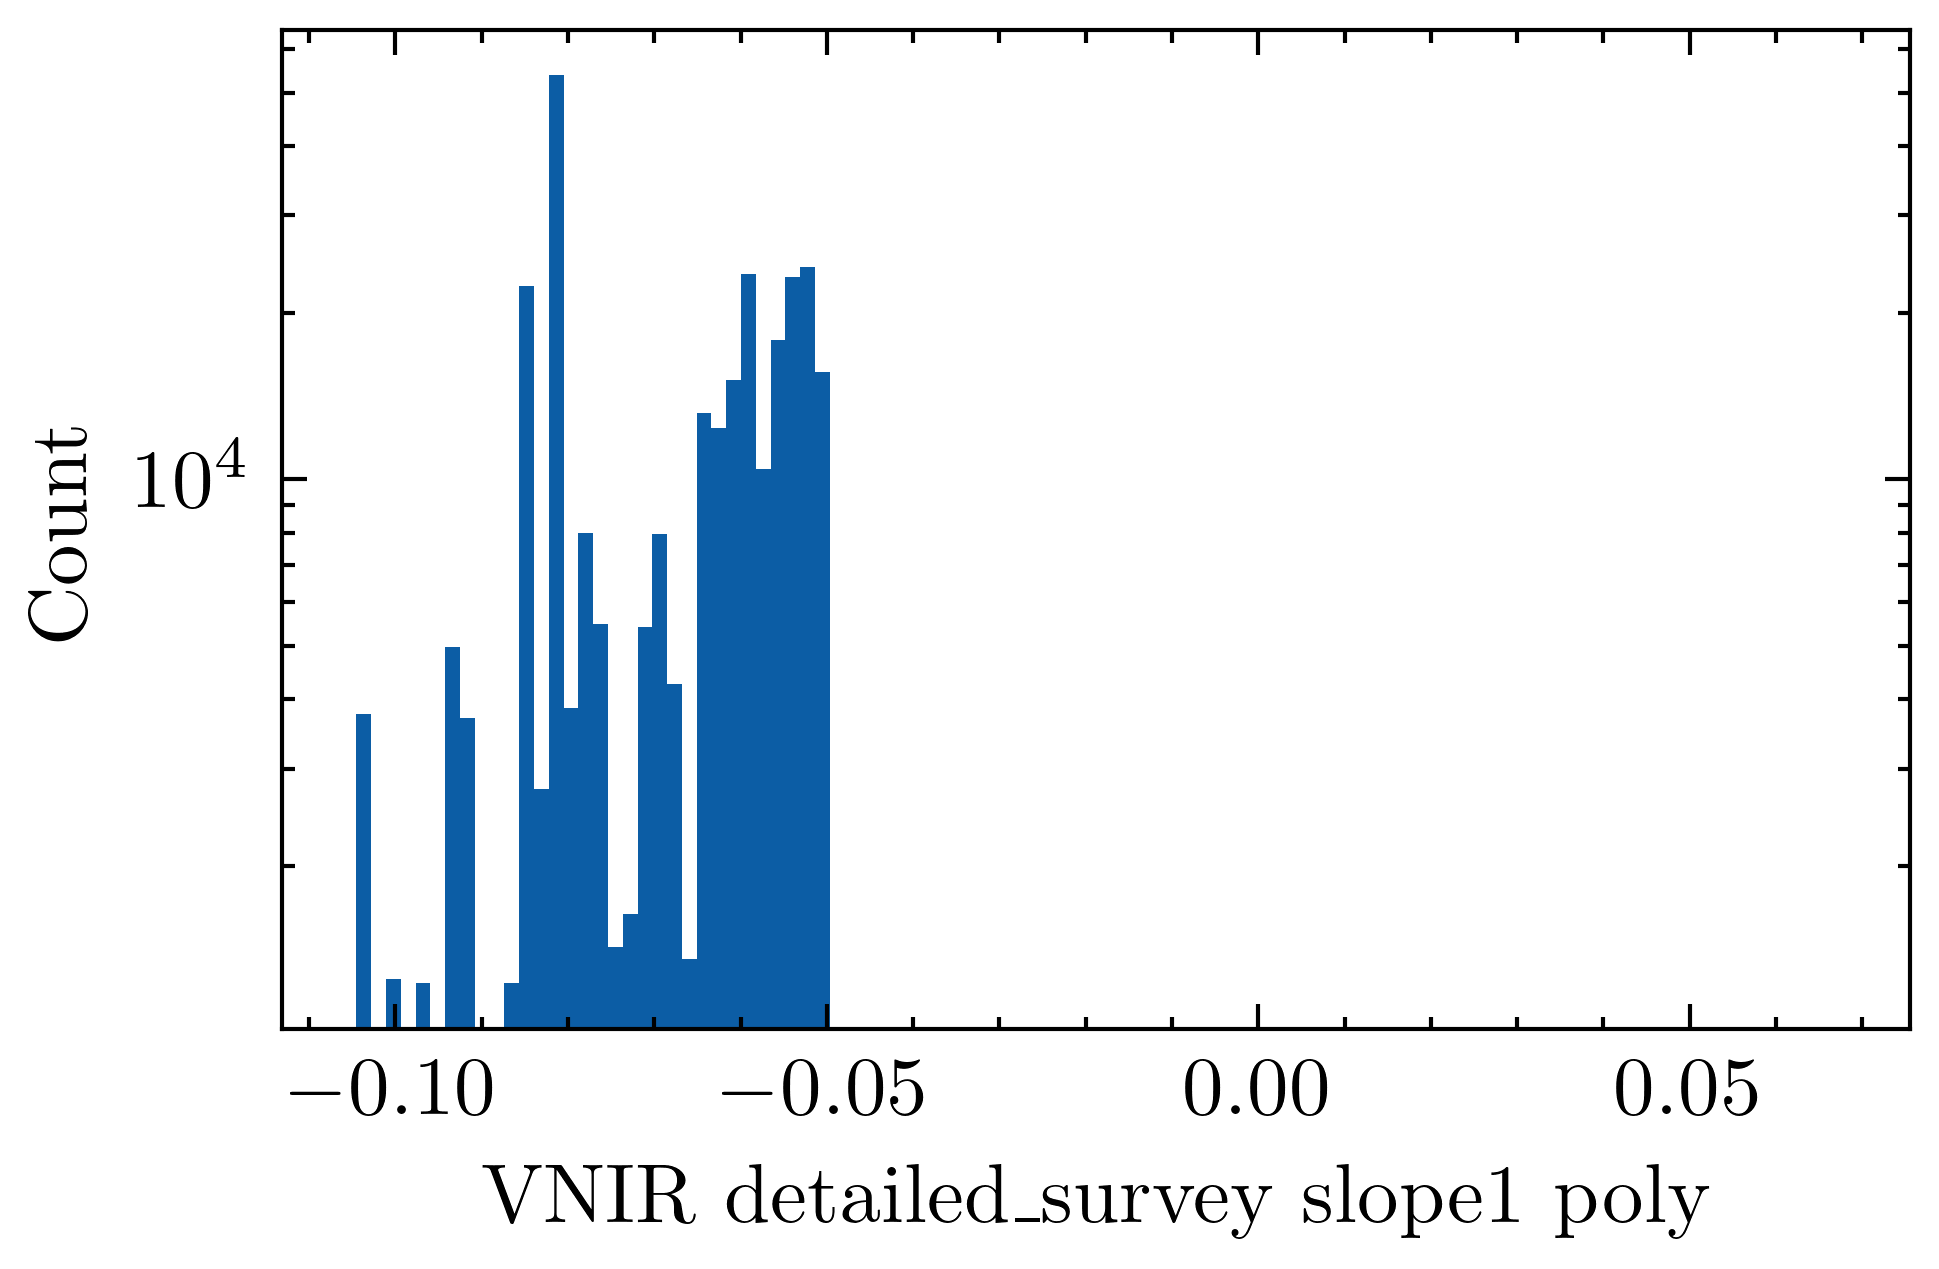

In [19]:
# Define the item we will be plotting
item = "VNIR detailed_survey slope1 poly"

# Find the range from the database
range = qm.get_column_extrema(item)

# Get the counts and bins for a linear binned hist (custom LazyFrame can be used if entered in the kwarg)
counts, bins = qm.get_column_hist(
    column = item,
    bin_range = range,
    bin_number = 100,
    custom_lf = qm.full_db.filter(pl.col(item) < -0.05)
)

# Plot the histogram data
plt.bar(
    bins[:-1],
    counts,
    width=np.diff(bins),
    align="edge",
)

plt.yscale("log")
plt.xlabel(item)
plt.ylabel("Count")
plt.show()